Classifier function - The CNN.

In [ ]:
#libraries imported
import tensorflow as tf #deep learning framework
import sklearn #ML library
import os #access to operating system
from tensorflow.keras import datasets, layers, models #keras for building and training
import numpy as np #maths library
import matplotlib.pyplot as plt #for plotting graphs

In [ ]:
#all the paths to the datasets
dataset_path   = '/content/content/drive/MyDrive/machine vision/splitdata' #original dataset
train_path = '/content/drive/MyDrive/dissertation/dataset/splitdataset/train'  #training dataset
validity_path = '/content/drive/MyDrive/dissertation/dataset/splitdataset/val' #validation dataset
test_path = '/content/drive/MyDrive/dissertation/dataset/splitdataset/test' #test dataset

In [ ]:
# creates the datasets using keras
# training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path, # training dataset path
    image_size=(224, 224),  # resizes pictures
    batch_size=16 # creates batch size
)
#validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    validity_path, # training dataset path
    image_size=(224, 224),  # resizes pictures
    batch_size=16 # creates batch size
)
#test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path, # training dataset path
    image_size=(224, 224),  # resizes pictures
    batch_size=16 # creates batch size
)

Found 734 files belonging to 2 classes.
Found 91 files belonging to 2 classes.
Found 94 files belonging to 2 classes.


In [ ]:
# creates model architecture
base_model = tf.keras.applications.EfficientNetB0( #efficientnetB0 model used
    include_top=False,        # exclude built-in head
    weights='imagenet',       # pretrained weights
    input_shape=(224, 224, 3) # dimensions expected from input images
)
# data augmentation step
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), # flips images horizontally
    tf.keras.layers.RandomRotation(0.2), # rotates images
    tf.keras.layers.RandomZoom(0.2), # zooms into images
    tf.keras.layers.RandomTranslation(0.1, 0.1) # translates images
])
# adds layers, activation functions and dropout
model = tf.keras.Sequential([
    data_augmentation,                        # augmentation
    base_model,                               # efficientnetB0 model
    tf.keras.layers.GlobalAveragePooling2D(), # creates single digit from feature map
    tf.keras.layers.Dense(64, activation='relu'), # hidden dense layer
    tf.keras.layers.Dropout(0.5), # dropout
    tf.keras.layers.Dense(1, activation='sigmoid') # binary output layer
])


In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', #monitors validity accuracy
    factor=0.5,    #halve learning rate
    patience=4,    #wait 4 epochs of no improvement
    min_lr=1e-7,  #don’t go below this
    min_delta=0.01 #ignore small changes
)

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', #monitors validation loss
    patience=10, #waits 10 epochs of no improvement
    restore_best_weights=True, #goes back to best loss
    min_delta=0.001 #threshold
)

callbacks = [reduce_lr, earlystop] #combines callbacks

In [ ]:
# training
# compiles model using training and validation datasets
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4), #compiles model, starting learning rate at 5e-4
       loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1), #binary loss function, label smoothing stops model being overconfident
       metrics=['accuracy'])
# trains model - 15 epochs
history = model.fit(train_dataset, validation_data=val_dataset, epochs=15, callbacks=[callbacks])

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 47s 181ms/step - accuracy: 0.5893 - loss: 0.6678 - val_accuracy: 0.7143 - val_loss: 0.5687 - learning_rate: 5.0000e-04
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.7894 - loss: 0.5268 - val_accuracy: 0.7473 - val_loss: 0.5804 - learning_rate: 5.0000e-04
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.7610 - loss: 0.5394 - val_accuracy: 0.7363 - val_loss: 0.5234 - learning_rate: 5.0000e-04
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.7892 - loss: 0.4977 - val_accuracy: 0.7363 - val_loss: 0.6292 - learning_rate: 5.0000e-04
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.8489 - loss: 0.4529 - val_accuracy: 0.6813 - val_loss: 0.6824 - learning_rate: 5.0000e-04
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8600 - loss: 0.4429 - val_accuracy: 0.7363 - val_loss: 0.5548 - learning_rate: 5.0000e-04
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy:

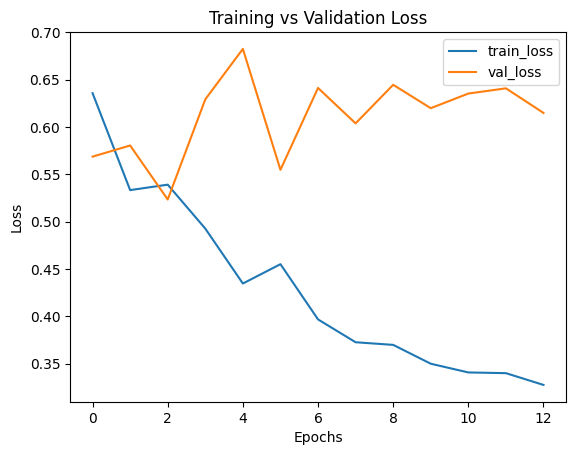

In [ ]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


GITHUB saving

In [1]:
from google.colab import userdata
pat = userdata.get('GITHUB_PAT')

In [2]:
!git config --global user.email "jacobmarkhunter@hotmail.com"
!git config --global user.name "JMHunter04"

In [ ]:
!git clone https://github.com/JMHunter04/Coral-Bleaching-Detection.git

Cloning into 'Coral-Bleaching-Detection'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 64 (delta 26), reused 32 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 47.21 KiB | 948.00 KiB/s, done.
Resolving deltas: 100% (26/26), done.


In [3]:
!cp /content/drive/MyDrive/dissertation/scripts/classifier.ipynb /content/Coral-Bleaching-Detection/mainscripts

In [4]:
%cd /content/Coral-Bleaching-Detection/
!git add mainscripts/classifier.ipynb
!git commit -m "reduceLR, early stopping and minor things added"
!git push origin main

/content/Coral-Bleaching-Detection
[main e53bd53] reduceLR, early stopping and minor things added
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite mainscripts/classifier.ipynb (97%)
Enumerating objects: 23, done.
Counting objects: 100% (23/23), done.
Delta compression using up to 12 threads
Compressing objects: 100% (20/20), done.
Writing objects: 100% (20/20), 41.10 KiB | 10.27 MiB/s, done.
Total 20 (delta 11), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (11/11), completed with 1 local object.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-prote